# Análisis exploratorio de datos estructurados

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#### Carga de datos

In [39]:
df_agricola = pd.read_csv('datos/produccion_agricola.csv')
df_agricola.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


In [40]:
#Valores nulos que existen
df_agricola.isnull().sum()

pais                    0
codigo_iso              0
region                  0
cultivo                 0
anio                    0
superficie_hectareas    0
rendimiento_ton_ha      0
produccion_ton          0
fertilizantes_kg_ha     0
agua_riego_m3_ha        0
tendencia_5_anios       0
dtype: int64

No existen valores nulos, de modo que no hay que imputar valores o elimiar filas.

Ahora vamos a crear una nueva variables que se puede llegar a tener en cuenta, como es: eficiencia del fertilizante. El porque de la creación de esta nueva variable es debido a que la eficiencia del fertilizante es un aspecto que se puede llegar a tener en cuenta en el caso de que se quiera hacer un estudio sobre la producción agrícola. Mide cuantas toneladas de alimento consigues por cada kilo de químico de la tierra. 

In [41]:
df_agricola['eficiencia_fertilizante'] = df_agricola['rendimiento_ton_ha'] / df_agricola['fertilizantes_kg_ha']
df_agricola.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios,eficiencia_fertilizante
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536,0.021143
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943,0.051524
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779,0.026381
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623,0.013008
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735,0.004275


In [50]:
df_agricola.describe()

,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios,eficiencia_fertilizante
count,1200.000000,1.200000e+03,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000
mean,2015.500000,2.351555e+06,12.878433,5.329724e+07,172.769167,5464.924167,-0.000749,0.093995
std,2.873479,2.379629e+06,27.418970,1.557934e+08,72.205648,2598.508894,0.028879,0.228420
min,2011.000000,9.770000e+02,0.430000,2.775000e+03,50.000000,1001.000000,-0.049991,0.002116
25%,2013.000000,4.013445e+05,2.227500,9.711170e+05,109.750000,3184.250000,-0.025279,0.012629
50%,2015.500000,1.589487e+06,3.500000,5.880648e+06,173.000000,5526.500000,-0.001155,0.022608
75%,2018.000000,3.447043e+06,5.932500,1.745015e+07,234.250000,7746.250000,0.023543,0.045048
max,2020.000000,1.263063e+07,158.450000,1.154381e+09,300.000000,9998.000000,0.049957,2.033529


#### Correlaciones entre variables

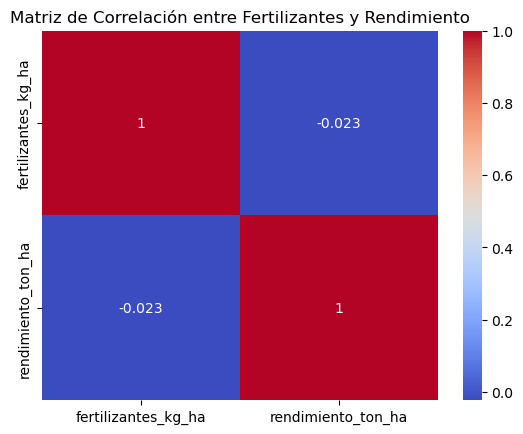

In [42]:
#Matriz de correlación para kg de fertilizante y rendimiento
correlation_matrix = df_agricola[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Fertilizantes y Rendimiento')
plt.show()

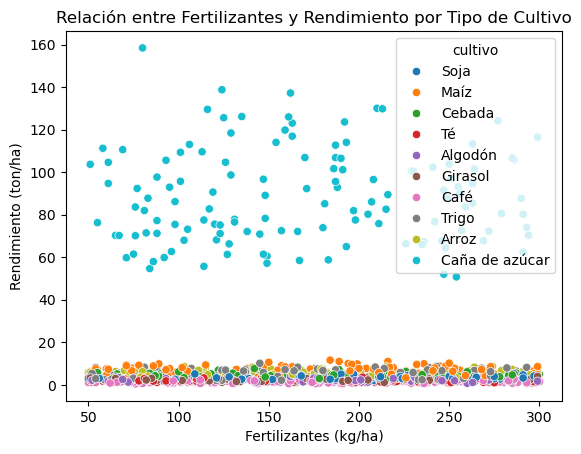

In [43]:
#Grafico de dispersión para kg de fertilizante y rendimiento por tipo de cultivo

sns.scatterplot(x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', data=df_agricola)
plt.title('Relación entre Fertilizantes y Rendimiento por Tipo de Cultivo')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.show()

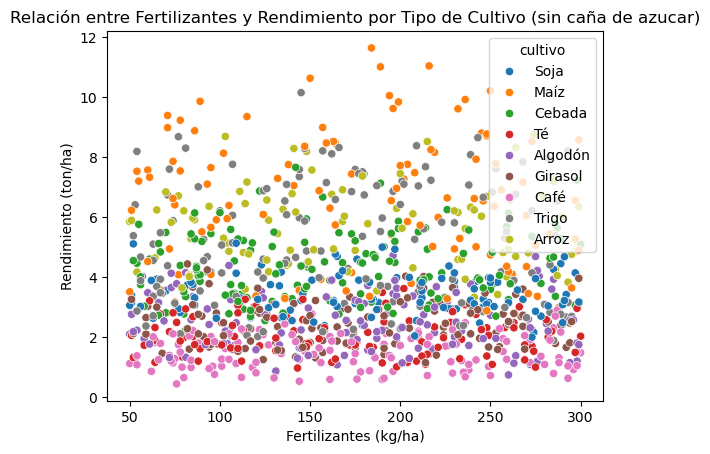

In [44]:
#Grafico de dispersión para kg de fertilizante y rendimiento quitando el cultivo de caña de azucar
df_sin_cana = df_agricola[df_agricola['cultivo'] != 'Caña de azúcar']
sns.scatterplot(x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', data=df_sin_cana)
plt.title('Relación entre Fertilizantes y Rendimiento por Tipo de Cultivo (sin caña de azucar)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.show()

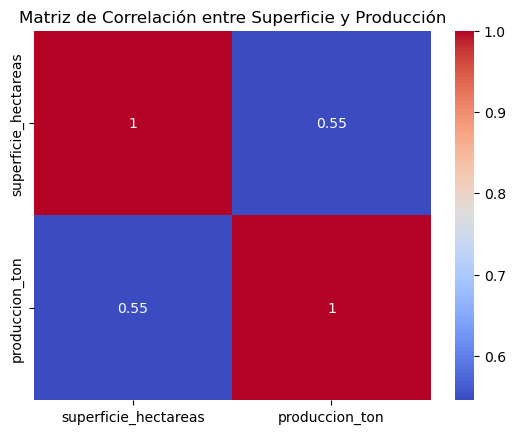

In [45]:
#Matriz de correlación para superficie y produccion
correlation_matrix = df_agricola[['superficie_hectareas', 'produccion_ton']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Superficie y Producción')
plt.show()

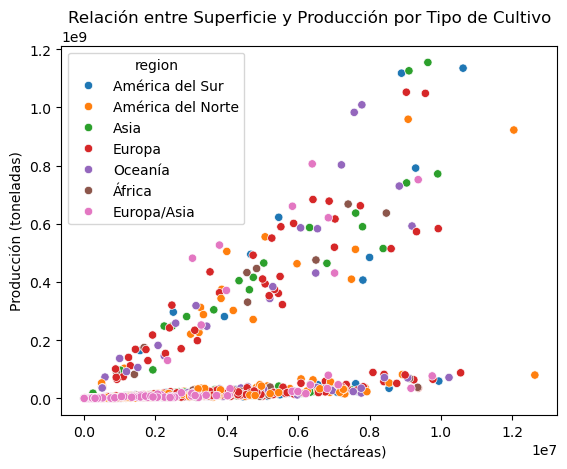

In [46]:
#Grafico de dispersión para kg de superficie y producción por tipo de cultivo

sns.scatterplot(x='superficie_hectareas', y='produccion_ton', hue='region', data=df_agricola)
plt.title('Relación entre Superficie y Producción por Tipo de Cultivo')
plt.xlabel('Superficie (hectáreas)')
plt.ylabel('Producción (toneladas)')
plt.show()

#### Análisis temporal

Tendencias por paises y cultivos

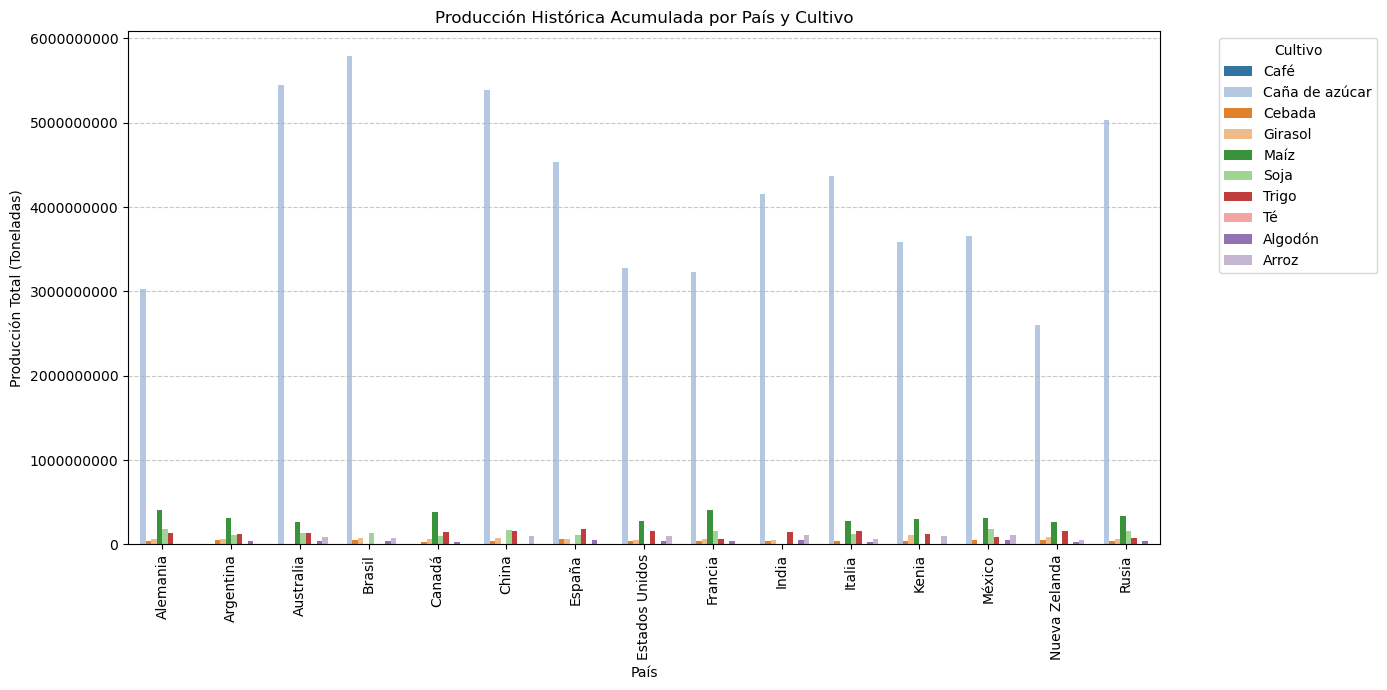

In [ ]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agricola.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

# Identificar producción total
paises = df_agricola.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo[prod_pais_cultivo['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

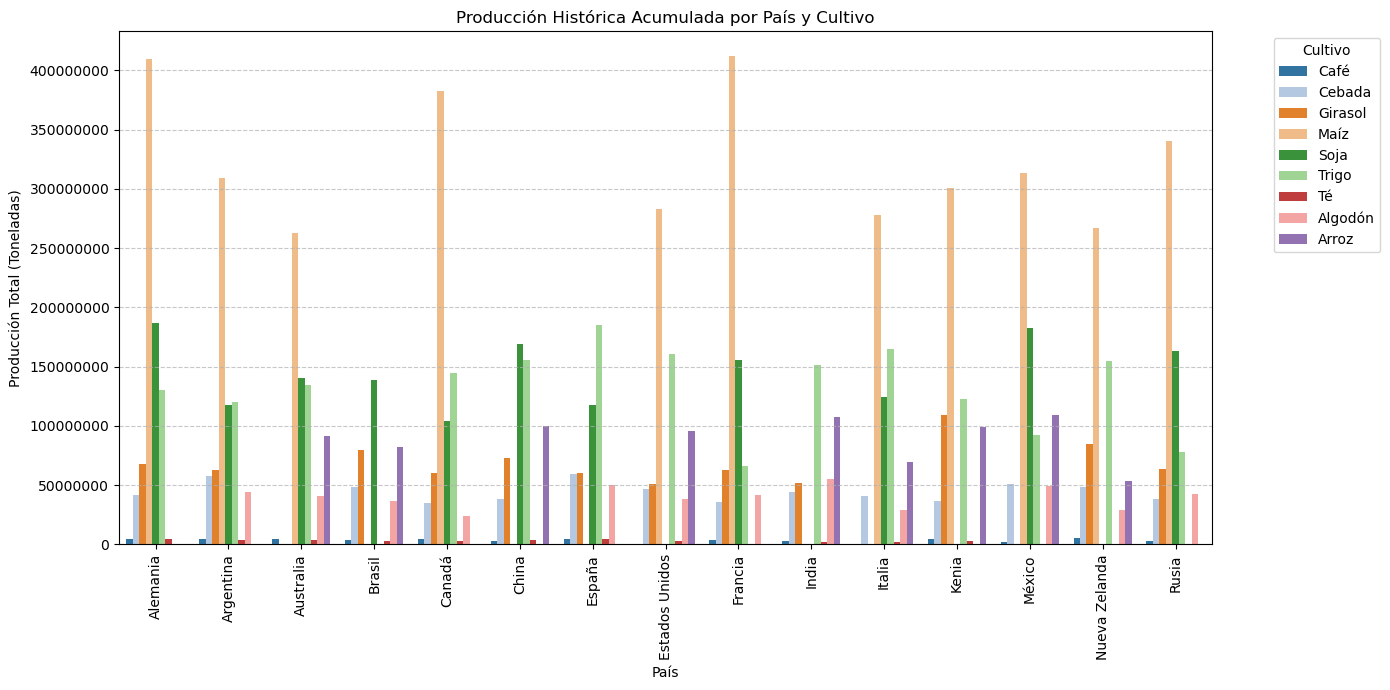

In [54]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agricola.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

prod_pais_cultivo_sin_cana = prod_pais_cultivo[prod_pais_cultivo['cultivo'] != 'Caña de azúcar']
# Identificar producción total
paises = df_agricola.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo_sin_cana[prod_pais_cultivo_sin_cana['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Anomalías en series temporales

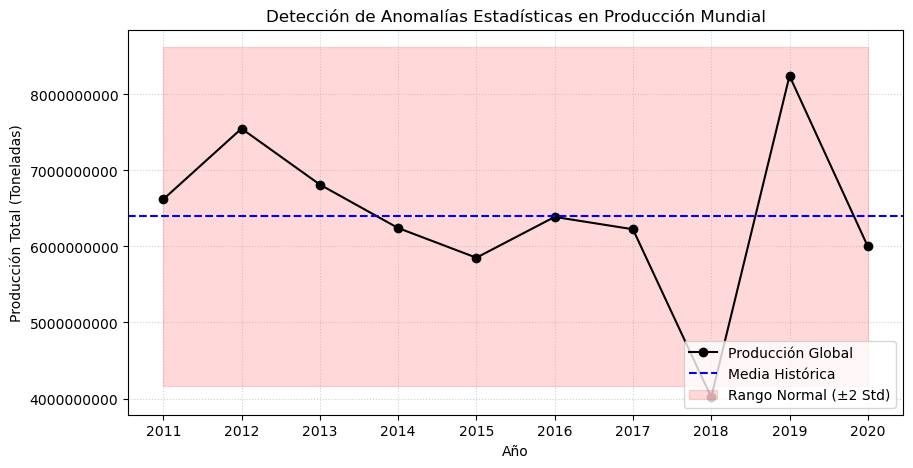

In [ ]:
# Agrupamos la producción global total por año
tendencia_global = df_agricola.groupby('anio')['produccion_ton'].sum().reset_index()

media_global = tendencia_global['produccion_ton'].mean()
std_global = tendencia_global['produccion_ton'].std()

plt.figure(figsize=(10, 5))
plt.plot(tendencia_global['anio'], tendencia_global['produccion_ton'], marker='o', color='purple', label='Producción Global Total')
plt.axhline(media_global, color='green', linestyle='--', label='Media Histórica')
plt.fill_between(tendencia_global['anio'], media_global - 2*std_global, media_global + 2*std_global, color='red', alpha=0.1, label='Rango Normal (±2 Std)')
plt.title('Detección de Anomalías: Producción Agrícola Global')
plt.xlabel('Año')
plt.ylabel('Producción Total (Toneladas)')
plt.xticks(range(2011, 2021))
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomalias_globales.png')
plt.close()

print("Producción global por año:")
print(tendencia_global)

Patrones estacionales

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_24884\2105625203.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')


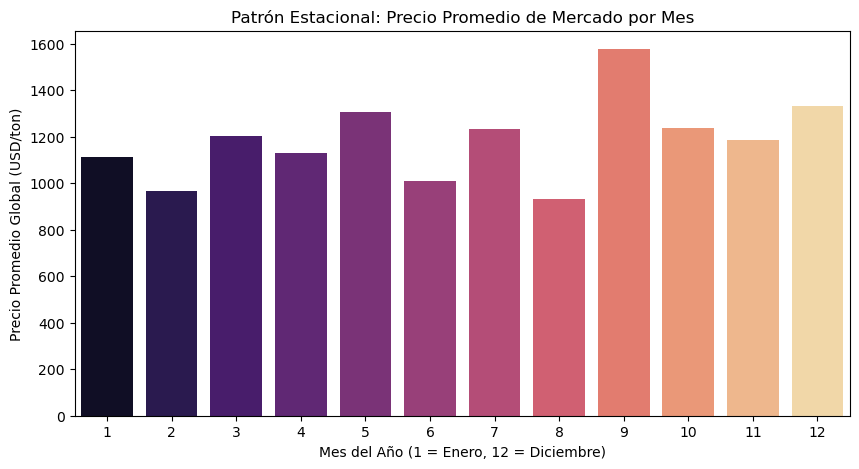

In [56]:
# Cargar el dataset de precios
df_precios = pd.read_csv('datos/precios_mercado.csv')

# Transformar la columna fecha para extraer el "Mes"
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])
df_precios['mes'] = df_precios['fecha'].dt.month

# Agrupar el precio promedio global por mes
estacionalidad_global = df_precios.groupby('mes')['precio_usd_ton'].mean().reset_index()

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')

plt.title('Patrón Estacional: Precio Promedio de Mercado por Mes')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Precio Promedio Global (USD/ton)')
plt.show()